In [1]:
# Cell 1 – imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Cell 2 – data loading
raw_records = [
    {
        'Author': 'Amer (2024)',
        'Method': 'Supervised Machine Learning (Random Forest)',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': '>94%', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': '0.75-0.80', 'Region': 'Texas, USA',
    },
    {
        'Author': 'Andrew et al. (2023)',
        'Method': 'Deep Learning CNN (U-Net)',
        'Sensor': 'NovaSAR-1, Sentinel-1',
        'OA_raw': '99%', 'F1_raw': '0.98', 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Australia',
    },
    {
        'Author': 'Toma et al. (2024)',
        'Method': 'Deep Learning Segmentation (U-Net)',
        'Sensor': 'Sentinel-1',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': '0.763',
        'Kappa_raw': None, 'Region': 'Romania, USA, Australia',
    },
    {
        'Author': 'Lahsaini et al. (2024)',
        'Method': 'Multi-temporal SAR-RST-FLOOD',
        'Sensor': 'Sentinel-1',
        'OA_raw': '>0.96', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': '>0.78', 'Region': 'England, Spain, Italy',
    },
    {
        'Author': 'Yailymov et al. (2025)',
        'Method': 'Random Forest, U-Net, MLP',
        'Sensor': 'Sentinel-1, Sentinel-2, Landsat-9',
        'OA_raw': '90.4%', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Ukraine',
    },
    {
        'Author': 'Honcharov & Hnatushenko (2025)',
        'Method': 'Deep Learning Semantic Segmentation (U-Net) combined with SVM',
        'Sensor': 'Sentinel-2',
        'OA_raw': '98.8%', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Ukraine',
    },
    {
        'Author': 'Cimpianu et al. (2021)',
        'Method': 'Thresholding, Gumbel distribution',
        'Sensor': 'Sentinel-1, Sentinel-2',
        'OA_raw': '>95%', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Prut River, Romania',
    },
    {
        'Author': 'Gasparovic & Klobucar (2021)',
        'Method': 'Object-Based Image Analysis (OBIA)',
        'Sensor': 'Sentinel-1, Sentinel-2',
        'OA_raw': '94.94%', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Croatia',
    },
    {
        'Author': 'Breznik et al. (2025)',
        'Method': 'Histogram thresholding compared with 2D Hydraulic Model',
        'Sensor': 'Sentinel-1',
        'OA_raw': '66%', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Slovenia',
    },
    {
        'Author': 'San Jose et al. (2025)',
        'Method': 'Deep Learning Segmentation (U-Net)',
        'Sensor': 'Sentinel-1',
        'OA_raw': None, 'F1_raw': '0.844-0.959', 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Global',
    },
    {
        'Author': 'Nemni et al. (2020)',
        'Method': 'Fully Convolutional Neural Network (CNN)',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': None, 'F1_raw': '>0.85', 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Myanmar, Global',
    },
    {
        'Author': 'Yang et al. (2021)',
        'Method': 'RAPID automated thresholding',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': '99.06%', 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'United States',
    },
    {
        'Author': 'Wieland et al. (2023)',
        'Method': 'Semantic Segmentation (EfficientNet-B4 + U-Net)',
        'Sensor': 'Sentinel-1, Sentinel-2',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': '0.8-0.9',
        'Kappa_raw': None, 'Region': 'Global',
    },
    {
        'Author': 'Usmani et al. (2025)',
        'Method': 'Backscatter thresholding, K-means, MNDWI',
        'Sensor': 'Sentinel-1, Sentinel-2, NOAA VIIRS, Landsat',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Pakistan',
    },
    {
        'Author': 'Islam & Meng (2022)',
        'Method': 'Automated thresholding via Google Earth Engine',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'United States',
    },
    {
        'Author': 'Tanim et al. (2022)',
        'Method': 'Support Vector Machine (SVM), Random Forest (RF), Maximum Likelihood Classifier (MLC)',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'California, USA',
    },
    {
        'Author': 'Pech-May et al. (2022)',
        'Method': 'Supervised Algorithms (SVM, RF, CART) via Google Earth Engine',
        'Sensor': 'Sentinel-2',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Mexico',
    },
    {
        'Author': 'Kunverji et al. (2021)',
        'Method': 'Decision Tree (DT), Random Forest (RF), Gradient Boosting (GB)',
        'Sensor': 'Optical imagery',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'India',
    },
    {
        'Author': 'Billah et al. (2023)',
        'Method': 'Random Forest (RF) Machine Learning',
        'Sensor': 'Sentinel-1 SAR, Sentinel-2',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Bangladesh',
    },
    {
        'Author': 'Cazals et al. (2016)',
        'Method': 'Hysteresis Thresholding',
        'Sensor': 'Sentinel-1',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'France',
    },
    {
        'Author': 'Bai et al. (2021)',
        'Method': 'Deep Learning Algorithms (CNN, BasNet)',
        'Sensor': 'Sentinel-1, Sentinel-2',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Bolivia, Global',
    },
    {
        'Author': 'Katiyar et al. (2021)',
        'Method': 'Deep Learning architectures (SegNet, U-Net)',
        'Sensor': 'Sentinel-1, Sentinel-2',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'India',
    },
    {
        'Author': 'Ngo et al. (2018)',
        'Method': 'Hybrid Swarm Optimized Multilayer Neural Network (FA-LM-ANN)',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Vietnam',
    },
    {
        'Author': 'Mateo-Garcia et al. (2021)',
        'Method': 'Fully Convolutional Neural Networks (FCNN)',
        'Sensor': 'Optical satellite imagery',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Global',
    },
    {
        'Author': 'Xing/Zhao et al. (2023)',
        'Method': 'FSA-UNet',
        'Sensor': 'Optical imagery',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Anhui Province, China',
    },
    {
        'Author': 'Sarker et al. (2019)',
        'Method': 'Convolutional Neural Networks (F-CNNs)',
        'Sensor': 'Landsat-5',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Australia',
    },
    {
        'Author': 'Xu et al. (2022)',
        'Method': 'Attention U-Net and multi-scale level set method',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'South China',
    },
    {
        'Author': 'Rambour et al. (2020)',
        'Method': 'Deep Learning (ResNet-50)',
        'Sensor': 'Sentinel-1, Sentinel-2',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Global',
    },
    {
        'Author': 'Dong et al. (2021)',
        'Method': 'Multiple Convolutional Neural Networks (CNN)',
        'Sensor': 'Sentinel-1',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'China',
    },
    {
        'Author': 'Singha et al. (2020)',
        'Method': 'Thresholding via Google Earth Engine',
        'Sensor': 'Sentinel-1',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Bangladesh, India',
    },
    {
        'Author': 'Zhao et al. (2022)',
        'Method': 'Urban-aware U-Net',
        'Sensor': 'Sentinel-1',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Global',
    },
    {
        'Author': 'Li et al. (2019)',
        'Method': 'Active self-learning Convolutional Neural Network (CNN)',
        'Sensor': 'TerraSAR-X',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Urban environments',
    },
    {
        'Author': 'Mudi et al. (2021)',
        'Method': 'SAR backscatter change detection / thresholding',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'India',
    },
    {
        'Author': 'Wang et al. (2022)',
        'Method': 'Repeat-Pass SAR Analysis',
        'Sensor': 'UAVSAR L-Band',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'North Carolina, USA',
    },
    {
        'Author': 'Denbina et al. (2020)',
        'Method': 'Convolutional Neural Networks (CNN)',
        'Sensor': 'UAVSAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'USA',
    },
    {
        'Author': 'Kundu et al. (2022)',
        'Method': 'Depth estimation from spatial inundation mapping',
        'Sensor': 'Sentinel-1, UAVSAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Texas, USA',
    },
    {
        'Author': 'Hitouri et al. (2024)',
        'Method': 'Machine Learning Algorithms (Susceptibility modeling)',
        'Sensor': 'SAR Data',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Morocco',
    },
    {
        'Author': 'Wu et al. (2025)',
        'Method': 'Convolutional Neural Networks (CNN)',
        'Sensor': 'Sentinel-1 SAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'China',
    },
    {
        'Author': 'Chini et al. (2019)',
        'Method': 'InSAR Coherence',
        'Sensor': 'Sentinel-1',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'Texas, USA',
    },
    {
        'Author': 'Clement et al. (2018)',
        'Method': 'Multi-temporal change detection',
        'Sensor': 'SAR',
        'OA_raw': None, 'F1_raw': None, 'IoU_raw': None,
        'Kappa_raw': None, 'Region': 'UK',
    },
]

df = pd.DataFrame(raw_records)
print(f"Dataset shape: {df.shape}")
df[['Author', 'Method', 'Sensor', 'OA_raw', 'F1_raw', 'IoU_raw', 'Kappa_raw']].head(10)


Dataset shape: (40, 8)


,Author,Method,Sensor,OA_raw,F1_raw,IoU_raw,Kappa_raw
0,Amer (2024),Supervised Machine Learning (Random Forest),Sentinel-1 SAR,>94%,NaN,NaN,0.75-0.80
1,Andrew et al. (2023),Deep Learning CNN (U-Net),"NovaSAR-1, Sentinel-1",99%,0.98,NaN,NaN
2,Toma et al. (2024),Deep Learning Segmentation (U-Net),Sentinel-1,NaN,NaN,0.763,NaN
3,Lahsaini et al. (2024),Multi-temporal SAR-RST-FLOOD,Sentinel-1,>0.96,NaN,NaN,>0.78
4,Yailymov et al. (2025),"Random Forest, U-Net, MLP","Sentinel-1, Sentinel-2, Landsat-9",90.4%,NaN,NaN,NaN
5,Honcharov & Hnatushenko (2025),Deep Learning Semantic Segmentation (U-Net) co...,Sentinel-2,98.8%,NaN,NaN,NaN
6,Cimpianu et al. (2021),"Thresholding, Gumbel distribution","Sentinel-1, Sentinel-2",>95%,NaN,NaN,NaN
7,Gasparovic & Klobucar (2021),Object-Based Image Analysis (OBIA),"Sentinel-1, Sentinel-2",94.94%,NaN,NaN,NaN
8,Breznik et al. (2025),Histogram thresholding compared with 2D Hydrau...,Sentinel-1,66%,NaN,NaN,NaN
9,San Jose et al. (2025),Deep Learning Segmentation (U-Net),Sentinel-1,NaN,0.844-0.959,NaN,NaN


In [3]:
# Cell 3 – cleaning and feature engineering

# ------- 1. Accuracy parser -------
def parse_accuracy(val):
    if val is None:
        return np.nan
    s = str(val).strip()
    # strip trailing text after % (e.g. "95% spatial agreement")
    s = re.sub(r'%.*$', '', s).strip()
    if not s:
        return np.nan
    # range: 0.84-0.95 or 0.84–0.95
    m = re.search(r'([0-9.]+)\s*[-\u2013]\s*([0-9.]+)', s)
    if m:
        lo, hi = float(m.group(1)), float(m.group(2))
        mid = (lo + hi) / 2.0
        return mid / 100.0 if mid > 1.0 else mid
    # inequality: >94 or >0.96
    m = re.search(r'[><=]+\s*([0-9.]+)', s)
    if m:
        num = float(m.group(1))
        return num / 100.0 if num > 1.0 else num
    # plain number
    m = re.search(r'([0-9.]+)', s)
    if m:
        num = float(m.group(1))
        return num / 100.0 if num > 1.0 else num
    return np.nan

for col in ['OA', 'F1', 'IoU', 'Kappa']:
    df[col] = df[f'{col}_raw'].apply(parse_accuracy)

# ------- 2. Method_Group -------
def classify_method(method):
    m = method.lower()
    dl_kw  = r'u-net|unet|cnn|fcnn|convolutional|resnet|segnet|basnet|fsa|efficientnet|attention u|deep learning|fully conv'
    ml_kw  = r'random forest|svm|support vector|decision tree|gradient boost|maximum likelihood|\bmlp\b|multilayer perceptron|\bcart\b|swarm|\bann\b'
    sar_kw = r'threshold|\bobia\b|insar|backscatter|change detect|sar-rst|repeat-pass|multi-temporal|hysteresis|\brapid\b|gumbel|depth estim'
    has_dl  = bool(re.search(dl_kw,  m))
    has_ml  = bool(re.search(ml_kw,  m))
    has_sar = bool(re.search(sar_kw, m))
    total   = has_dl + has_ml + has_sar
    if total > 1:
        return 'Hybrid'
    if has_dl:
        return 'DL'
    if has_ml:
        return 'ML'
    if has_sar:
        return 'SAR'
    return 'SAR'   # fallback for generic SAR ops (InSAR, Repeat-Pass)

df['Method_Group'] = df['Method'].apply(classify_method)

# manual overrides for edge cases
df.loc[df['Author'] == 'Chini et al. (2019)', 'Method_Group'] = 'SAR'
df.loc[df['Author'] == 'Wang et al. (2022)',  'Method_Group'] = 'SAR'
df.loc[df['Author'] == 'Kundu et al. (2022)', 'Method_Group'] = 'SAR'
df.loc[df['Author'] == 'Ngo et al. (2018)',   'Method_Group'] = 'Hybrid'
df.loc[df['Author'] == 'Usmani et al. (2025)','Method_Group'] = 'Hybrid'

# ------- 3. Sensor_Type -------
def classify_sensor(sensor):
    s = sensor.lower()
    has_sar     = bool(re.search(r'sentinel-1|terrasar|uavsar|\bsar\b|novasar|l-band', s))
    has_optical = bool(re.search(r'sentinel-2|landsat|optical|viirs|modis|worldfloods', s))
    if has_sar and has_optical:
        return 'Multi'
    if has_optical:
        return 'Optical'
    return 'SAR'   # SAR or generic SAR Data

df['Sensor_Type'] = df['Sensor'].apply(classify_sensor)

# ------- 4. Accuracy_Main (priority: F1 > OA > IoU) -------
def get_accuracy_main(row):
    for col in ['F1', 'OA', 'IoU']:
        if not np.isnan(row[col]):
            return row[col]
    return np.nan

df['Accuracy_Main'] = df.apply(get_accuracy_main, axis=1)

df_clean = df[['Author', 'Method', 'Sensor', 'OA', 'F1', 'IoU', 'Kappa',
               'Region', 'Method_Group', 'Sensor_Type', 'Accuracy_Main']].copy()

print(df_clean[['Author', 'Method_Group', 'Sensor_Type', 'OA', 'F1', 'IoU', 'Accuracy_Main']].to_string())
print(f"\nStudies with numeric Accuracy_Main : {df_clean['Accuracy_Main'].notna().sum()} / {len(df_clean)}")


                            Author Method_Group Sensor_Type      OA      F1    IoU  Accuracy_Main
0                      Amer (2024)           ML         SAR  0.9400     NaN    NaN         0.9400
1             Andrew et al. (2023)           DL         SAR  0.9900  0.9800    NaN         0.9800
2               Toma et al. (2024)           DL         SAR     NaN     NaN  0.763         0.7630
3           Lahsaini et al. (2024)          SAR         SAR  0.9600     NaN    NaN         0.9600
4           Yailymov et al. (2025)       Hybrid       Multi  0.9040     NaN    NaN         0.9040
5   Honcharov & Hnatushenko (2025)       Hybrid     Optical  0.9880     NaN    NaN         0.9880
6           Cimpianu et al. (2021)          SAR       Multi  0.9500     NaN    NaN         0.9500
7     Gasparovic & Klobucar (2021)          SAR       Multi  0.9494     NaN    NaN         0.9494
8            Breznik et al. (2025)          SAR         SAR  0.6600     NaN    NaN         0.6600
9           San Jose

In [4]:
# Cell 4 – analysis

print("=" * 60)
print("Mean / Min / Max / Std of Accuracy_Main per Method_Group")
print("=" * 60)
grp_stats = (
    df_clean
    .groupby('Method_Group')['Accuracy_Main']
    .agg(count='count', mean='mean', min='min', max='max', std='std')
    .round(4)
    .sort_values('mean', ascending=False)
)
print(grp_stats.to_string())

print()
print("=" * 60)
print("Accuracy_Main distribution per Sensor_Type")
print("=" * 60)
sensor_stats = (
    df_clean
    .groupby('Sensor_Type')['Accuracy_Main']
    .agg(count='count', mean='mean', min='min', max='max', std='std')
    .round(4)
    .sort_values('mean', ascending=False)
)
print(sensor_stats.to_string())

print()
print("=" * 60)
print("Study count per Method_Group")
print("=" * 60)
print(df_clean['Method_Group'].value_counts().to_string())

print()
print("=" * 60)
print("Study count per Sensor_Type")
print("=" * 60)
print(df_clean['Sensor_Type'].value_counts().to_string())


Mean / Min / Max / Std of Accuracy_Main per Method_Group
              count    mean    min     max     std
Method_Group                                      
Hybrid            2  0.9460  0.904  0.9880  0.0594
ML                1  0.9400  0.940  0.9400     NaN
SAR               5  0.9020  0.660  0.9906  0.1363
DL                5  0.8689  0.763  0.9800  0.0796

Accuracy_Main distribution per Sensor_Type
             count    mean    min     max     std
Sensor_Type                                      
Optical          1  0.9880  0.988  0.9880     NaN
Multi            4  0.9134  0.850  0.9500  0.0474
SAR              8  0.8806  0.660  0.9906  0.1169

Study count per Method_Group
Method_Group
DL        17
SAR       14
ML         5
Hybrid     4

Study count per Sensor_Type
Sensor_Type
SAR        25
Multi       9
Optical     6


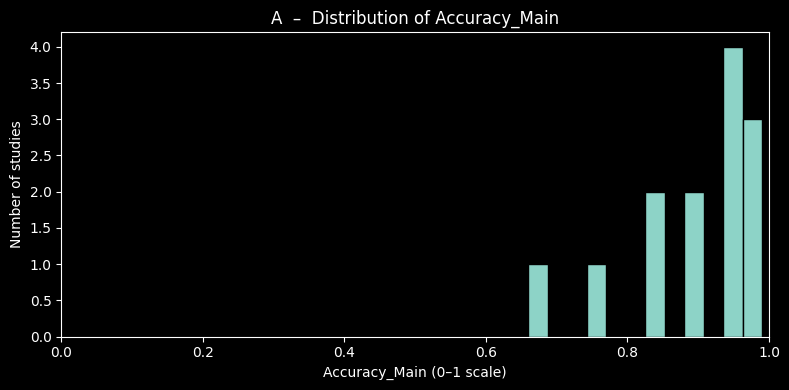

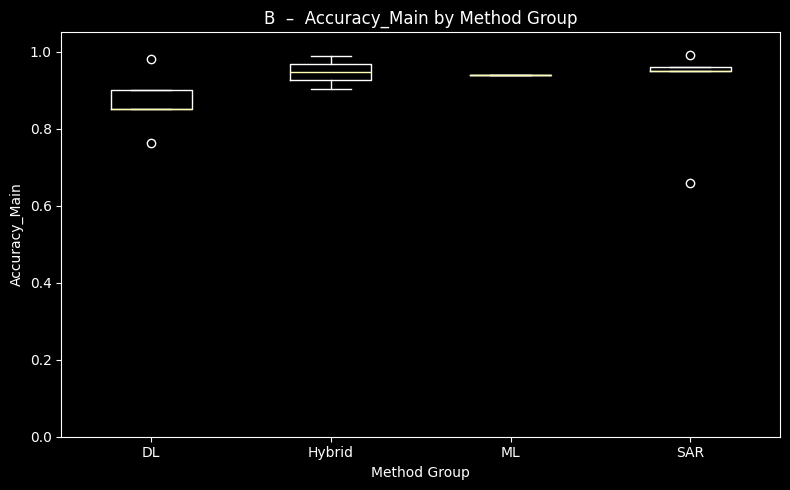

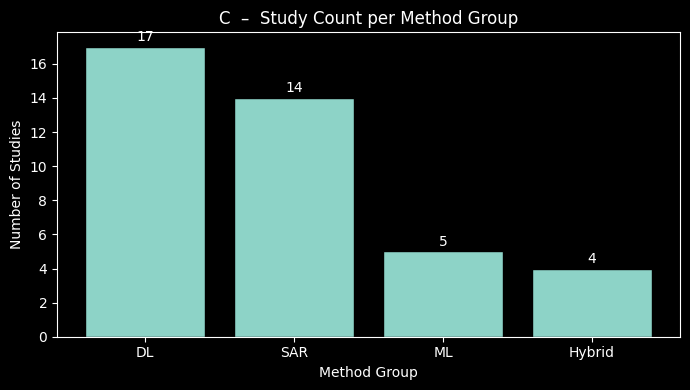

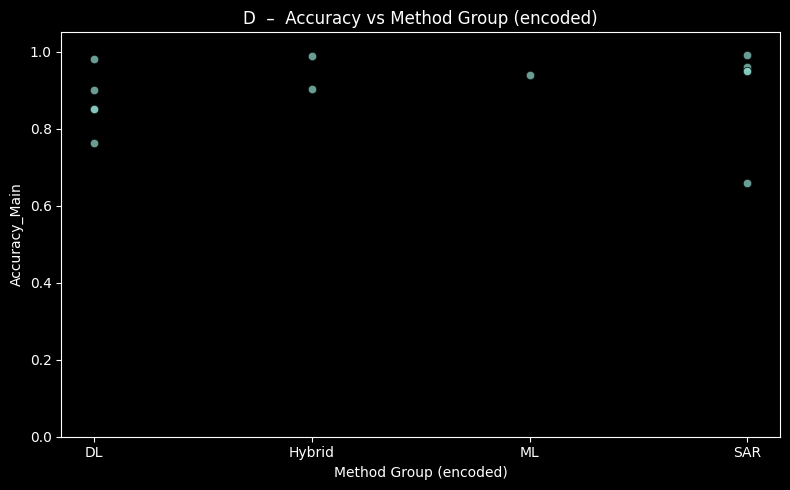

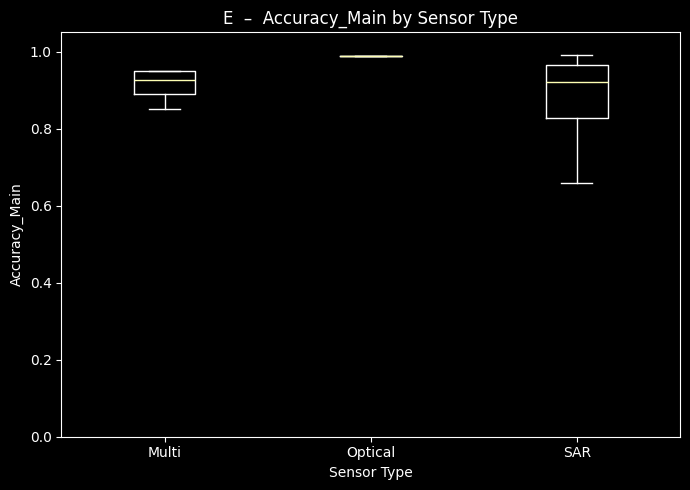

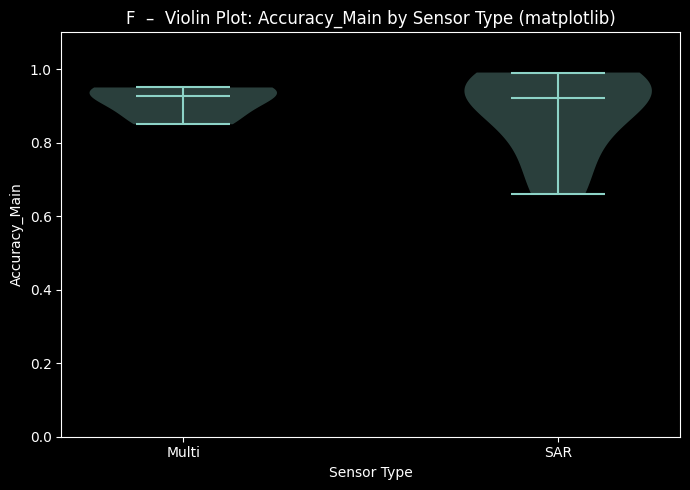

In [5]:
# Cell 5 – visualization  (A–F, one chart per figure, matplotlib only)

acc = df_clean.dropna(subset=['Accuracy_Main']).copy()

# ── A: Histogram of Accuracy_Main ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(acc['Accuracy_Main'], bins=12, edgecolor='black')
ax.set_xlabel('Accuracy_Main (0–1 scale)')
ax.set_ylabel('Number of studies')
ax.set_title('A  –  Distribution of Accuracy_Main')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('plot_A_histogram.png', dpi=150)
plt.show()

# ── B: Boxplot – Accuracy_Main by Method_Group ─────────────────────────────
groups  = df_clean.groupby('Method_Group')['Accuracy_Main'].apply(
    lambda x: x.dropna().tolist()
)
labels  = groups.index.tolist()
data_bp = groups.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_bp, labels=labels, patch_artist=False)
ax.set_xlabel('Method Group')
ax.set_ylabel('Accuracy_Main')
ax.set_title('B  –  Accuracy_Main by Method Group')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('plot_B_boxplot_method.png', dpi=150)
plt.show()

# ── C: Bar chart – studies per Method_Group ────────────────────────────────
counts = df_clean['Method_Group'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, edgecolor='black')
ax.set_xlabel('Method Group')
ax.set_ylabel('Number of Studies')
ax.set_title('C  –  Study Count per Method Group')
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.15, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('plot_C_bar_method.png', dpi=150)
plt.show()

# ── D: Scatter – Accuracy_Main vs Method (numeric encoding) ───────────────
method_map  = {g: i for i, g in enumerate(sorted(df_clean['Method_Group'].unique()))}
acc_scatter = df_clean.dropna(subset=['Accuracy_Main']).copy()
acc_scatter['Method_Code'] = acc_scatter['Method_Group'].map(method_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(acc_scatter['Method_Code'], acc_scatter['Accuracy_Main'],
           alpha=0.75, edgecolors='black', linewidths=0.5)
ax.set_xticks(list(method_map.values()))
ax.set_xticklabels(list(method_map.keys()))
ax.set_xlabel('Method Group (encoded)')
ax.set_ylabel('Accuracy_Main')
ax.set_title('D  –  Accuracy vs Method Group (encoded)')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('plot_D_scatter.png', dpi=150)
plt.show()

# ── E: Boxplot – Accuracy_Main by Sensor_Type ─────────────────────────────
sensor_groups = df_clean.groupby('Sensor_Type')['Accuracy_Main'].apply(
    lambda x: x.dropna().tolist()
)
s_labels = sensor_groups.index.tolist()
s_data   = sensor_groups.tolist()

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(s_data, labels=s_labels, patch_artist=False)
ax.set_xlabel('Sensor Type')
ax.set_ylabel('Accuracy_Main')
ax.set_title('E  –  Accuracy_Main by Sensor Type')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('plot_E_boxplot_sensor.png', dpi=150)
plt.show()

# ── F: Violin plot approximation (matplotlib) ─────────────────────────────
# matplotlib violinplot requires >= 2 data points per group
violin_data   = [v for v in s_data if len(v) >= 2]
violin_labels = [l for l, v in zip(s_labels, s_data) if len(v) >= 2]

fig, ax = plt.subplots(figsize=(7, 5))
parts = ax.violinplot(violin_data, positions=range(len(violin_data)),
                      showmedians=True, showextrema=True)
ax.set_xticks(range(len(violin_labels)))
ax.set_xticklabels(violin_labels)
ax.set_xlabel('Sensor Type')
ax.set_ylabel('Accuracy_Main')
ax.set_title('F  –  Violin Plot: Accuracy_Main by Sensor Type (matplotlib)')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('plot_F_violin.png', dpi=150)
plt.show()


Pearson correlation matrix (OA, F1, IoU):
      OA   F1  IoU
OA   1.0  NaN  NaN
F1   NaN  1.0  NaN
IoU  NaN  NaN  1.0


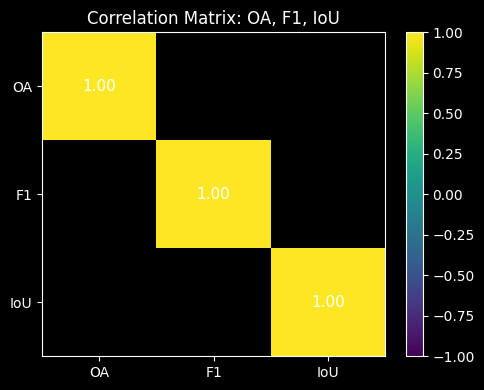

In [6]:
# Cell 6 – Optional: correlation matrix (OA, F1, IoU)

metrics = df_clean[['OA', 'F1', 'IoU']].dropna(how='all')
corr    = metrics.corr(min_periods=2)

print("Pearson correlation matrix (OA, F1, IoU):")
print(corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix: OA, F1, IoU')
plt.tight_layout()
plt.savefig('plot_correlation_matrix.png', dpi=150)
plt.show()


KMeans cluster assignments:
                        Author Method_Group  Cluster     OA     F1   IoU
                   Amer (2024)           ML        0 0.9400    NaN   NaN
            Toma et al. (2024)           DL        0    NaN    NaN 0.763
        Lahsaini et al. (2024)          SAR        0 0.9600    NaN   NaN
        Yailymov et al. (2025)       Hybrid        0 0.9040    NaN   NaN
        Cimpianu et al. (2021)          SAR        0 0.9500    NaN   NaN
Honcharov & Hnatushenko (2025)       Hybrid        0 0.9880    NaN   NaN
  Gasparovic & Klobucar (2021)          SAR        0 0.9494    NaN   NaN
        San Jose et al. (2025)           DL        0    NaN 0.9015   NaN
            Yang et al. (2021)          SAR        0 0.9906    NaN   NaN
           Nemni et al. (2020)           DL        0    NaN 0.8500   NaN
         Wieland et al. (2023)           DL        0    NaN    NaN 0.850
         Breznik et al. (2025)          SAR        1 0.6600    NaN   NaN
          Andrew et al.

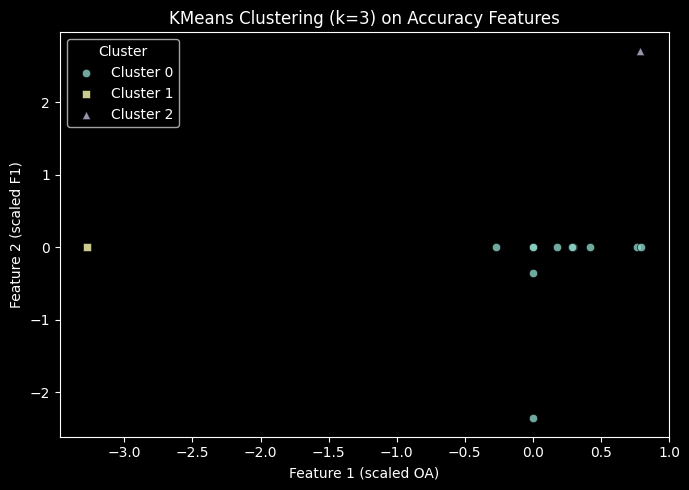

In [7]:
# Cell 7 – Optional: KMeans clustering on accuracy values

features = df_clean[['OA', 'F1', 'IoU', 'Kappa']].copy()

# impute missing with column mean before clustering
col_means = features.mean()
features  = features.fillna(col_means)

# studies with at least one real metric
has_data_mask = df_clean[['OA', 'F1', 'IoU', 'Kappa']].notna().any(axis=1)
X             = features[has_data_mask].values
authors       = df_clean.loc[has_data_mask, 'Author'].values
method_groups = df_clean.loc[has_data_mask, 'Method_Group'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 3
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

df_clustered = pd.DataFrame({
    'Author'      : authors,
    'Method_Group': method_groups,
    'Cluster'     : labels,
    'OA'          : df_clean.loc[has_data_mask, 'OA'].values,
    'F1'          : df_clean.loc[has_data_mask, 'F1'].values,
    'IoU'         : df_clean.loc[has_data_mask, 'IoU'].values,
})

print("KMeans cluster assignments:")
print(df_clustered.sort_values('Cluster').to_string(index=False))
print()
print("Cluster summary (mean OA / F1 / IoU per cluster):")
print(df_clustered.groupby('Cluster')[['OA', 'F1', 'IoU']].mean().round(4).to_string())

# scatter: first two scaled features, coloured by cluster (greyscale)
markers = ['o', 's', '^', 'D', 'P']
fig, ax = plt.subplots(figsize=(7, 5))
for c in range(n_clusters):
    mask = labels == c
    grey = str(0.2 + 0.3 * c)
    ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
               marker=markers[c % len(markers)],
               label=f'Cluster {c}',
               edgecolors='black', linewidths=0.5, alpha=0.8)
ax.set_xlabel('Feature 1 (scaled OA)')
ax.set_ylabel('Feature 2 (scaled F1)')
ax.set_title(f'KMeans Clustering (k={n_clusters}) on Accuracy Features')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('plot_kmeans_clusters.png', dpi=150)
plt.show()
